# 🚀 Deep Learning 101 - Batch 2079 - Amsterdam

## 📚 Libraries

In [65]:
# data manipulation
import numpy as np
import pandas as pd

# data viz
import matplotlib.pyplot as plt

# preprocessing
from sklearn.preprocessing import StandardScaler

# dataset
from tensorflow.keras.datasets import california_housing

# keras
from tensorflow.keras import Sequential, layers

# skleanr
from sklearn.ensemble import RandomForestRegressor

## 💾 Dataset

👉 Toy datasets available in TensorflowKeras: click [here](https://www.tensorflow.org/api_docs/python/tf/keras/datasets)



In [22]:
(x_train, y_train), (x_test, y_test) = california_housing.load_data()

743530/743530 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [23]:
x_train.shape

(16512, 8)

In [43]:
pd.DataFrame(x_train)

,0,1,2,3,4,5,6,7
0,-118.269997,34.090000,52.0,2327.0,555.0,1048.0,491.0,3.7847
1,-118.360001,33.959999,21.0,1802.0,556.0,1286.0,557.0,2.7284
2,-122.389999,37.759998,52.0,1877.0,427.0,712.0,398.0,3.9722
3,-117.949997,33.919998,11.0,3127.0,706.0,1594.0,694.0,4.3426
4,-122.519997,37.919998,24.0,421.0,64.0,163.0,75.0,14.5833
...,...,...,...,...,...,...,...,...
16507,-122.029999,37.349998,19.0,3811.0,1227.0,1930.0,1153.0,3.5154
16508,-118.440002,34.189999,19.0,3487.0,959.0,2278.0,835.0,2.6709
16509,-122.339996,37.570000,52.0,2547.0,373.0,876.0,359.0,8.2598
16510,-122.180000,37.889999,18.0,4845.0,735.0,1634.0,734.0,8.1489


In [29]:
x_test.shape

(4128, 8)

In [30]:
y_train

array([252300., 146900., 290900., ..., 500001., 499000., 238100.],
      dtype=float32)

In [31]:
y_test

array([397900., 227900., 172100., ...,  98800., 234600., 100000.],
      dtype=float32)

## 🔢 Scaling features

In [34]:
scaler = StandardScaler()
scaler.fit(x_train)

StandardScaler()

In [35]:
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

## 🧠 My First Neural Network

### 🛠️ 1- Building the architecture of the model

In [45]:
x_train_scaled.shape[-1]

8

In [76]:
model = Sequential()
# INPUT LAYER
model.add(layers.Input(shape=(x_train_scaled.shape[-1],)))
# HIDDEN LAYERS
model.add(layers.Dense(16, activation="relu"))
model.add(layers.Dense(8, activation="relu"))
# PREDICTIVE LAYER
model.add(layers.Dense(1, activation="linear"))

In [77]:
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_33 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

### 👨🏻‍🏫 2- Compiling the model

***model.fit***

*   which **loss function** should the model minimize ?
*   which optimizer (solver) should the model use the minimize the loss function ?


***model.score***
* specifiy on which metrics (it can be a list of several metrics) will the model be evaluated?



In [78]:
model.compile(
    loss="mean_squared_error",
    optimizer="adam",
    metrics = ["r2_score"]
)

In [79]:
# model.compile(
#     loss="binary_crossentropy", # "log loss in sklearn"
#                                # regression task for "mse"
#     optimizer="adam",
#     metrics = ["accuracy", "precision", "recall"]
# )

### 🥋 3- Train the model

In [80]:
history = model.fit(x_train_scaled,
                  y_train,
                  validation_split = 0.20,
                  batch_size = 32,
                  epochs = 100
)

Epoch 1/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 55621877760.0000 - r2_score: -3.2508 - val_loss: 56686645248.0000 - val_r2_score: -3.1782
Epoch 2/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 56001818624.0000 - r2_score: -3.2039 - val_loss: 56503316480.0000 - val_r2_score: -3.1647
Epoch 3/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 55651192832.0000 - r2_score: -3.2529 - val_loss: 56041373696.0000 - val_r2_score: -3.1306
Epoch 4/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 54543040512.0000 - r2_score: -3.1890 - val_loss: 55213613056.0000 - val_r2_score: -3.0696
Epoch 5/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 54651404288.0000 - r2_score: -3.1234 - val_loss: 53987966976.0000 - val_r2_score: -2.9793
Epoch 6/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 53615284224.0000 - r2_score: -2.9780 - val_loss: 52355129344.0000 - val_r2_score: -2.8589
Epoch 7/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 51851907072.0000 - r2_score: -2.8

In [81]:
history.history.keys()

dict_keys(['loss', 'r2_score', 'val_loss', 'val_r2_score'])

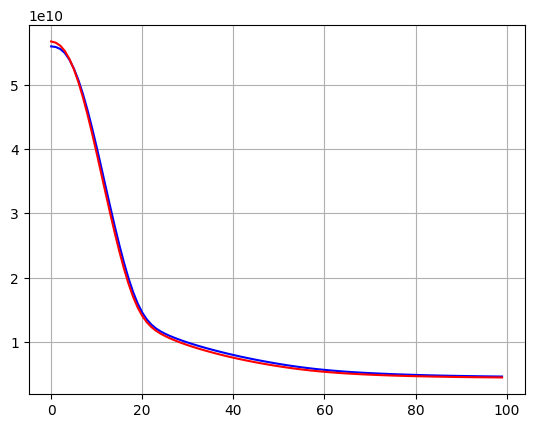

In [82]:
plt.plot(history.history["loss"], c="b")
plt.plot(history.history["val_loss"], c="r")
plt.grid()
plt.show();

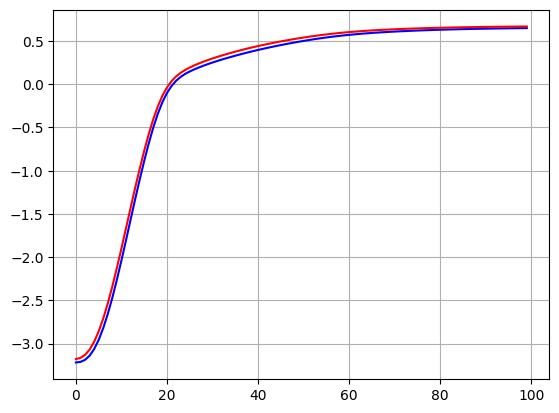

In [83]:
plt.plot(history.history["r2_score"], c="b")
plt.plot(history.history["val_r2_score"], c="r")
plt.grid()
plt.show();

In [55]:
nb_datapoints_train = len(x_train_scaled)
nb_datapoints_train

16512

In [56]:
batch_size = 32

In [57]:
nb_datapoints_train/batch_size

516.0

### 🥇4- Evaluate the model on the train set

In [62]:
model.evaluate(x_train_scaled, y_train)

516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 9621360640.0000 - r2_score: 0.2750


[9457368064.0, 0.29002809524536133]

In [59]:
# model.score(x_test_scaled, y_test)

model.evaluate(x_test_scaled, y_test)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9565503488.0000 - r2_score: 0.2738


[9089520640.0, 0.31628692150115967]

## 🤖 Comparision with Machine Learning

In [61]:
forest = RandomForestRegressor()
forest.fit(x_train_scaled, y_train)
forest.score(x_test_scaled, y_test)

0.8129572992865917